In [72]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
from codes import OpticalData, Fault
import numpy as np

optical = OpticalData(ew_filepath="/Users/hintont/Dev/projects/Ridgecrest/data/EW_Ridgecrest_1m_utm_detrended.tif", ns_filepath="/Users/hintont/Dev/projects/Ridgecrest/data/NS_Ridgecrest_1m_utm_detrended.tif", verbose=False)
optical = optical.decimate(100)
optical = optical.clear_nan()

fault = Fault(filepath="/Users/hintont/Dev/projects/Ridgecrest/data/fault_trace.shp", crs=optical.ew.rio.crs)
profiles = fault.gen_profiles()
profiles = optical.evaluate_profiles(profiles)
# optical.plot(fault=fault, profiles=profiles, ns=False)

profile_i = 3
profile = profiles[profile_i]

xs = profile.xs
data = profile.displacements[1]
noise_level=0.05
data_covariance = noise_level**2 * np.eye(xs.size)

In [74]:
from codes import HamiltonianInversion, UniformDist, TwoDDzForwardModel

n_patches = 16

priors = [UniformDist("dz_halfwidth", 0., 1000.)] + [UniformDist(f"slip{i}", -10, 0) for i in range(n_patches)]

forward_model = TwoDDzForwardModel()
forward_model = forward_model.build_uniform_patches(n_patches, 10000.)
forward_model.xs = xs

inversion = HamiltonianInversion(forward_model, priors, data, data_covariance)
inversion = inversion.run()

Starting inversion...
Linear estimation of gradient in Greens function (17)
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 
... estimation complete:
Cholesky factorisation...
... factorisation complete.


/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: divide by zero encountered in matmul
  return (core_func(*inputs),)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: overflow encountered in matmul
  return (core_func(*inputs),)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: invalid value encountered in matmul
  return (core_func(*inputs),)
Initializing NUTS using jitter+adapt_diag...
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: divide by zero encountered in matmul
  return (core_func(*inputs),)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/blockwise.py:514: RuntimeWarning: overflow encountered in matmul
  return (core_func(*inputs),)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/bl

/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/math.py:3026: RuntimeWarning: divide by zero encountered in matmul
  output_storage[0][0] = np.matmul(*inputs)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/math.py:3026: RuntimeWarning: overflow encountered in matmul
  output_storage[0][0] = np.matmul(*inputs)
/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/pytensor/tensor/math.py:3026: RuntimeWarning: invalid value encountered in matmul
  output_storage[0][0] = np.matmul(*inputs)
Sampling: [obs]


/Users/hintont/Dev/codes/.venv/lib/python3.14/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Slip (m)', ylabel='Depth (m)'>,
        <Axes: xlabel='Displacement from fault (m)', ylabel='Vertical displacement (m)'>],
       dtype=object))

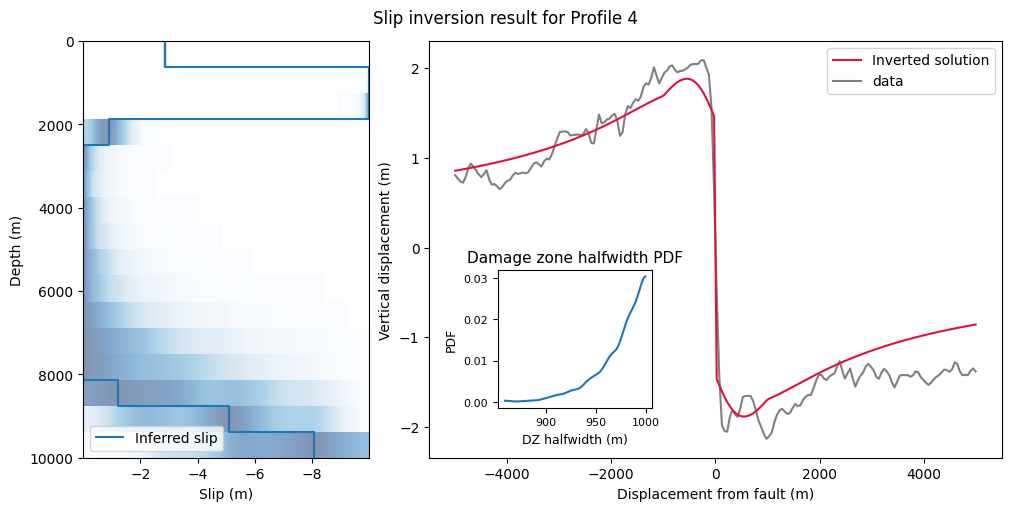

In [75]:
forward_model = TwoDDzForwardModel()
forward_model = forward_model.build_uniform_patches(n_patches, 10000.)
forward_model.xs = xs

forward_model.plot_inversion_result(inversion.result, data, plot_kwargs={"invert_slip_x_axis": True}, title=f"Slip inversion result for Profile {profile_i+1}")

                 mean      sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
dz_halfwidth  972.977  23.956  926.906  999.951      0.347    0.399    3186.0   
slip0          -2.857   0.035   -2.921   -2.787      0.001    0.001    4027.0   
slip1          -9.971   0.031  -10.000   -9.915      0.000    0.001    2785.0   
slip2          -9.869   0.123  -10.000   -9.644      0.002    0.003    3072.0   
slip3          -0.880   0.478   -1.664   -0.002      0.009    0.006    2229.0   
slip4          -0.391   0.372   -1.079   -0.000      0.006    0.008    3216.0   
slip5          -0.390   0.382   -1.108   -0.000      0.005    0.008    3703.0   
slip6          -0.461   0.439   -1.289   -0.000      0.006    0.010    3846.0   
slip7          -0.602   0.600   -1.681   -0.000      0.009    0.015    3313.0   
slip8          -0.834   0.800   -2.280   -0.000      0.012    0.018    3455.0   
slip9          -1.141   1.128   -3.098   -0.000      0.017    0.028    3372.0   
slip10         -1.612   1.49

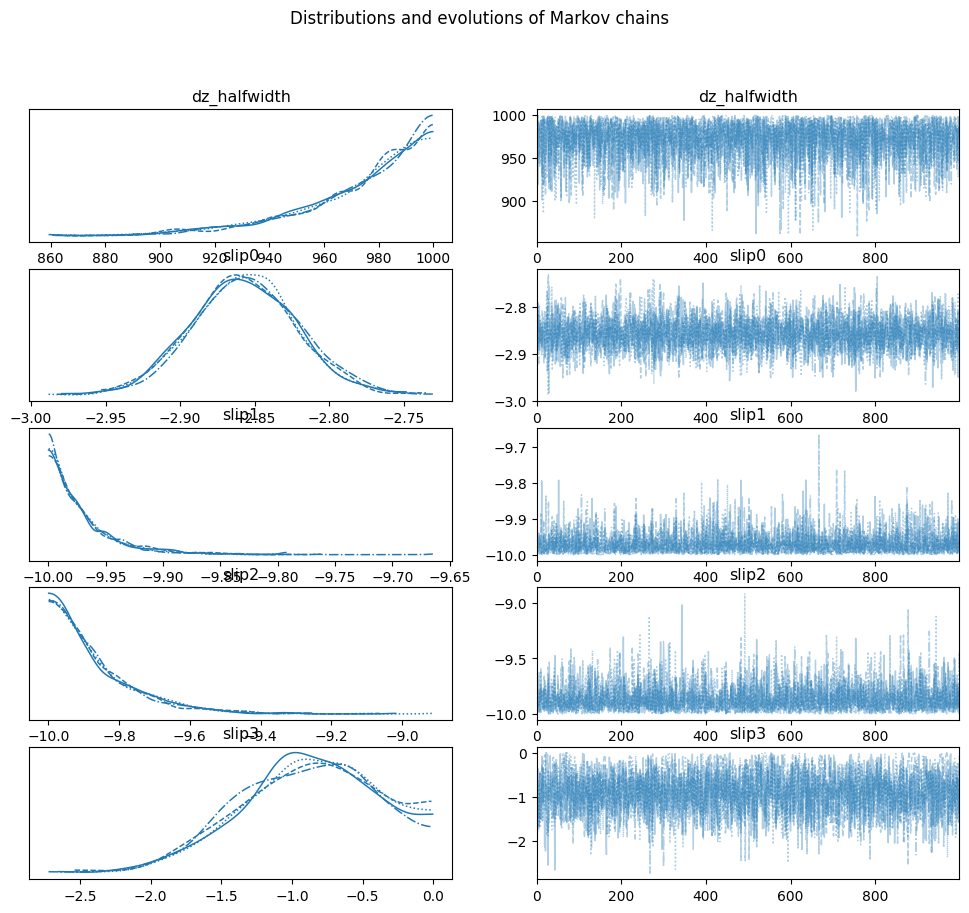

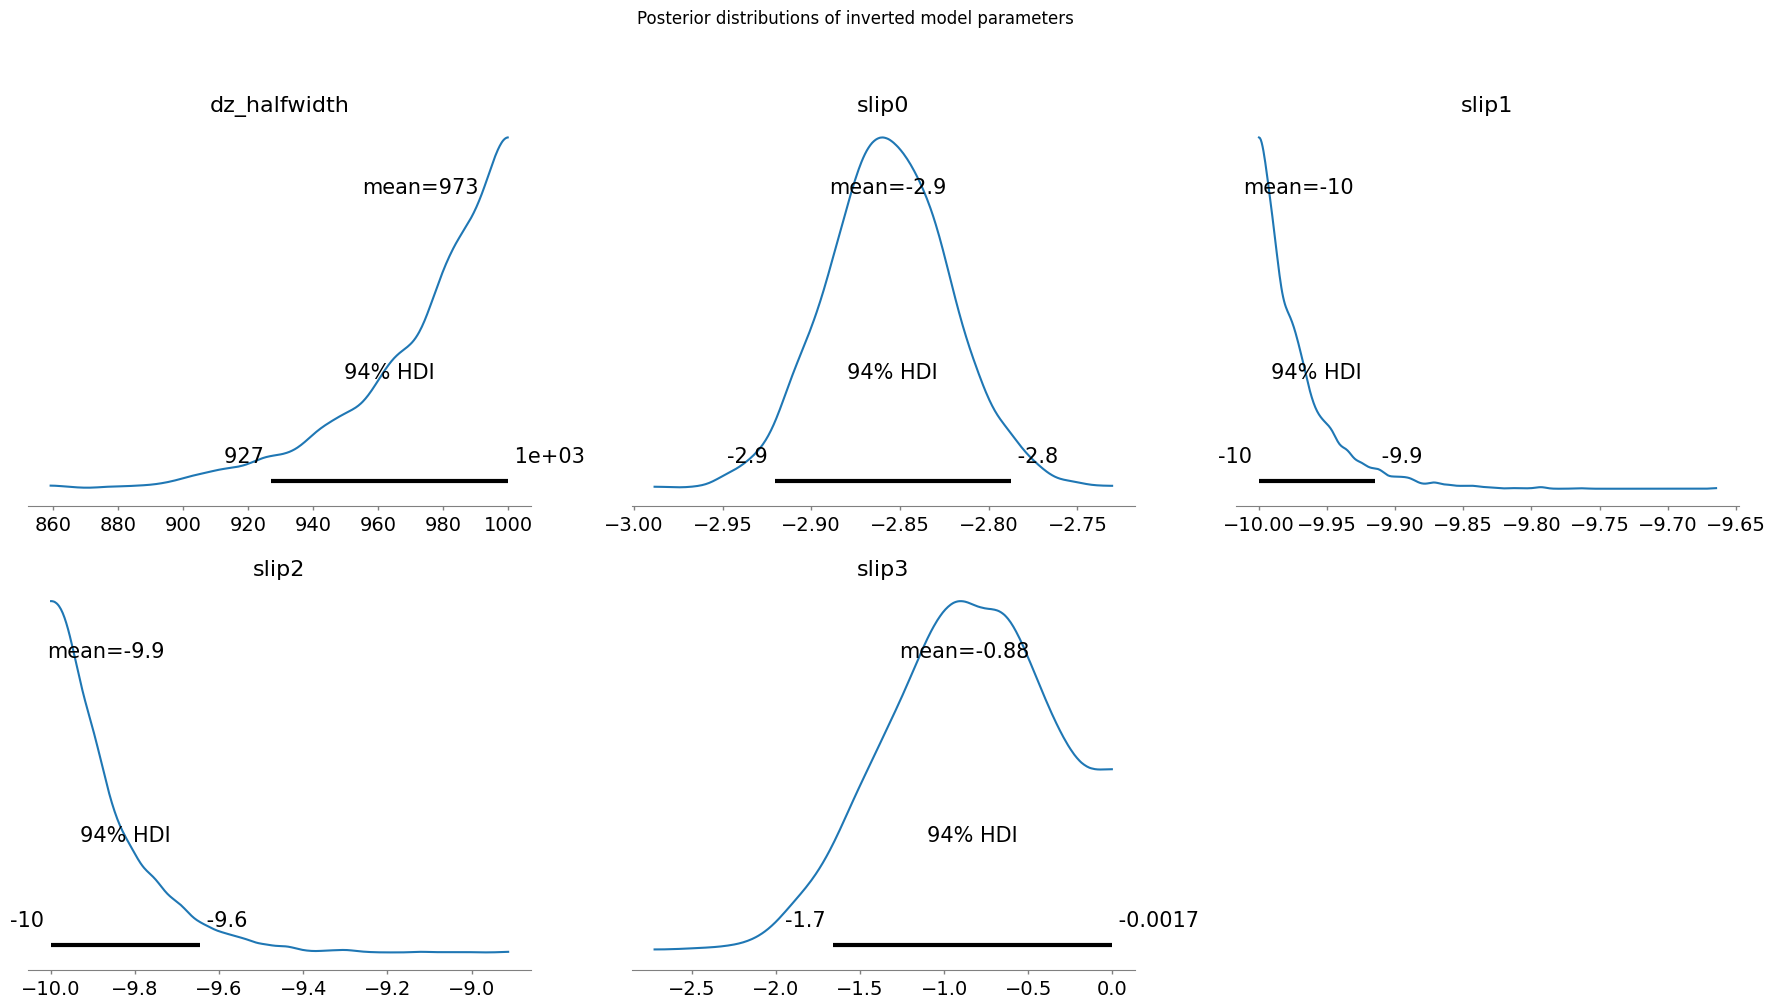

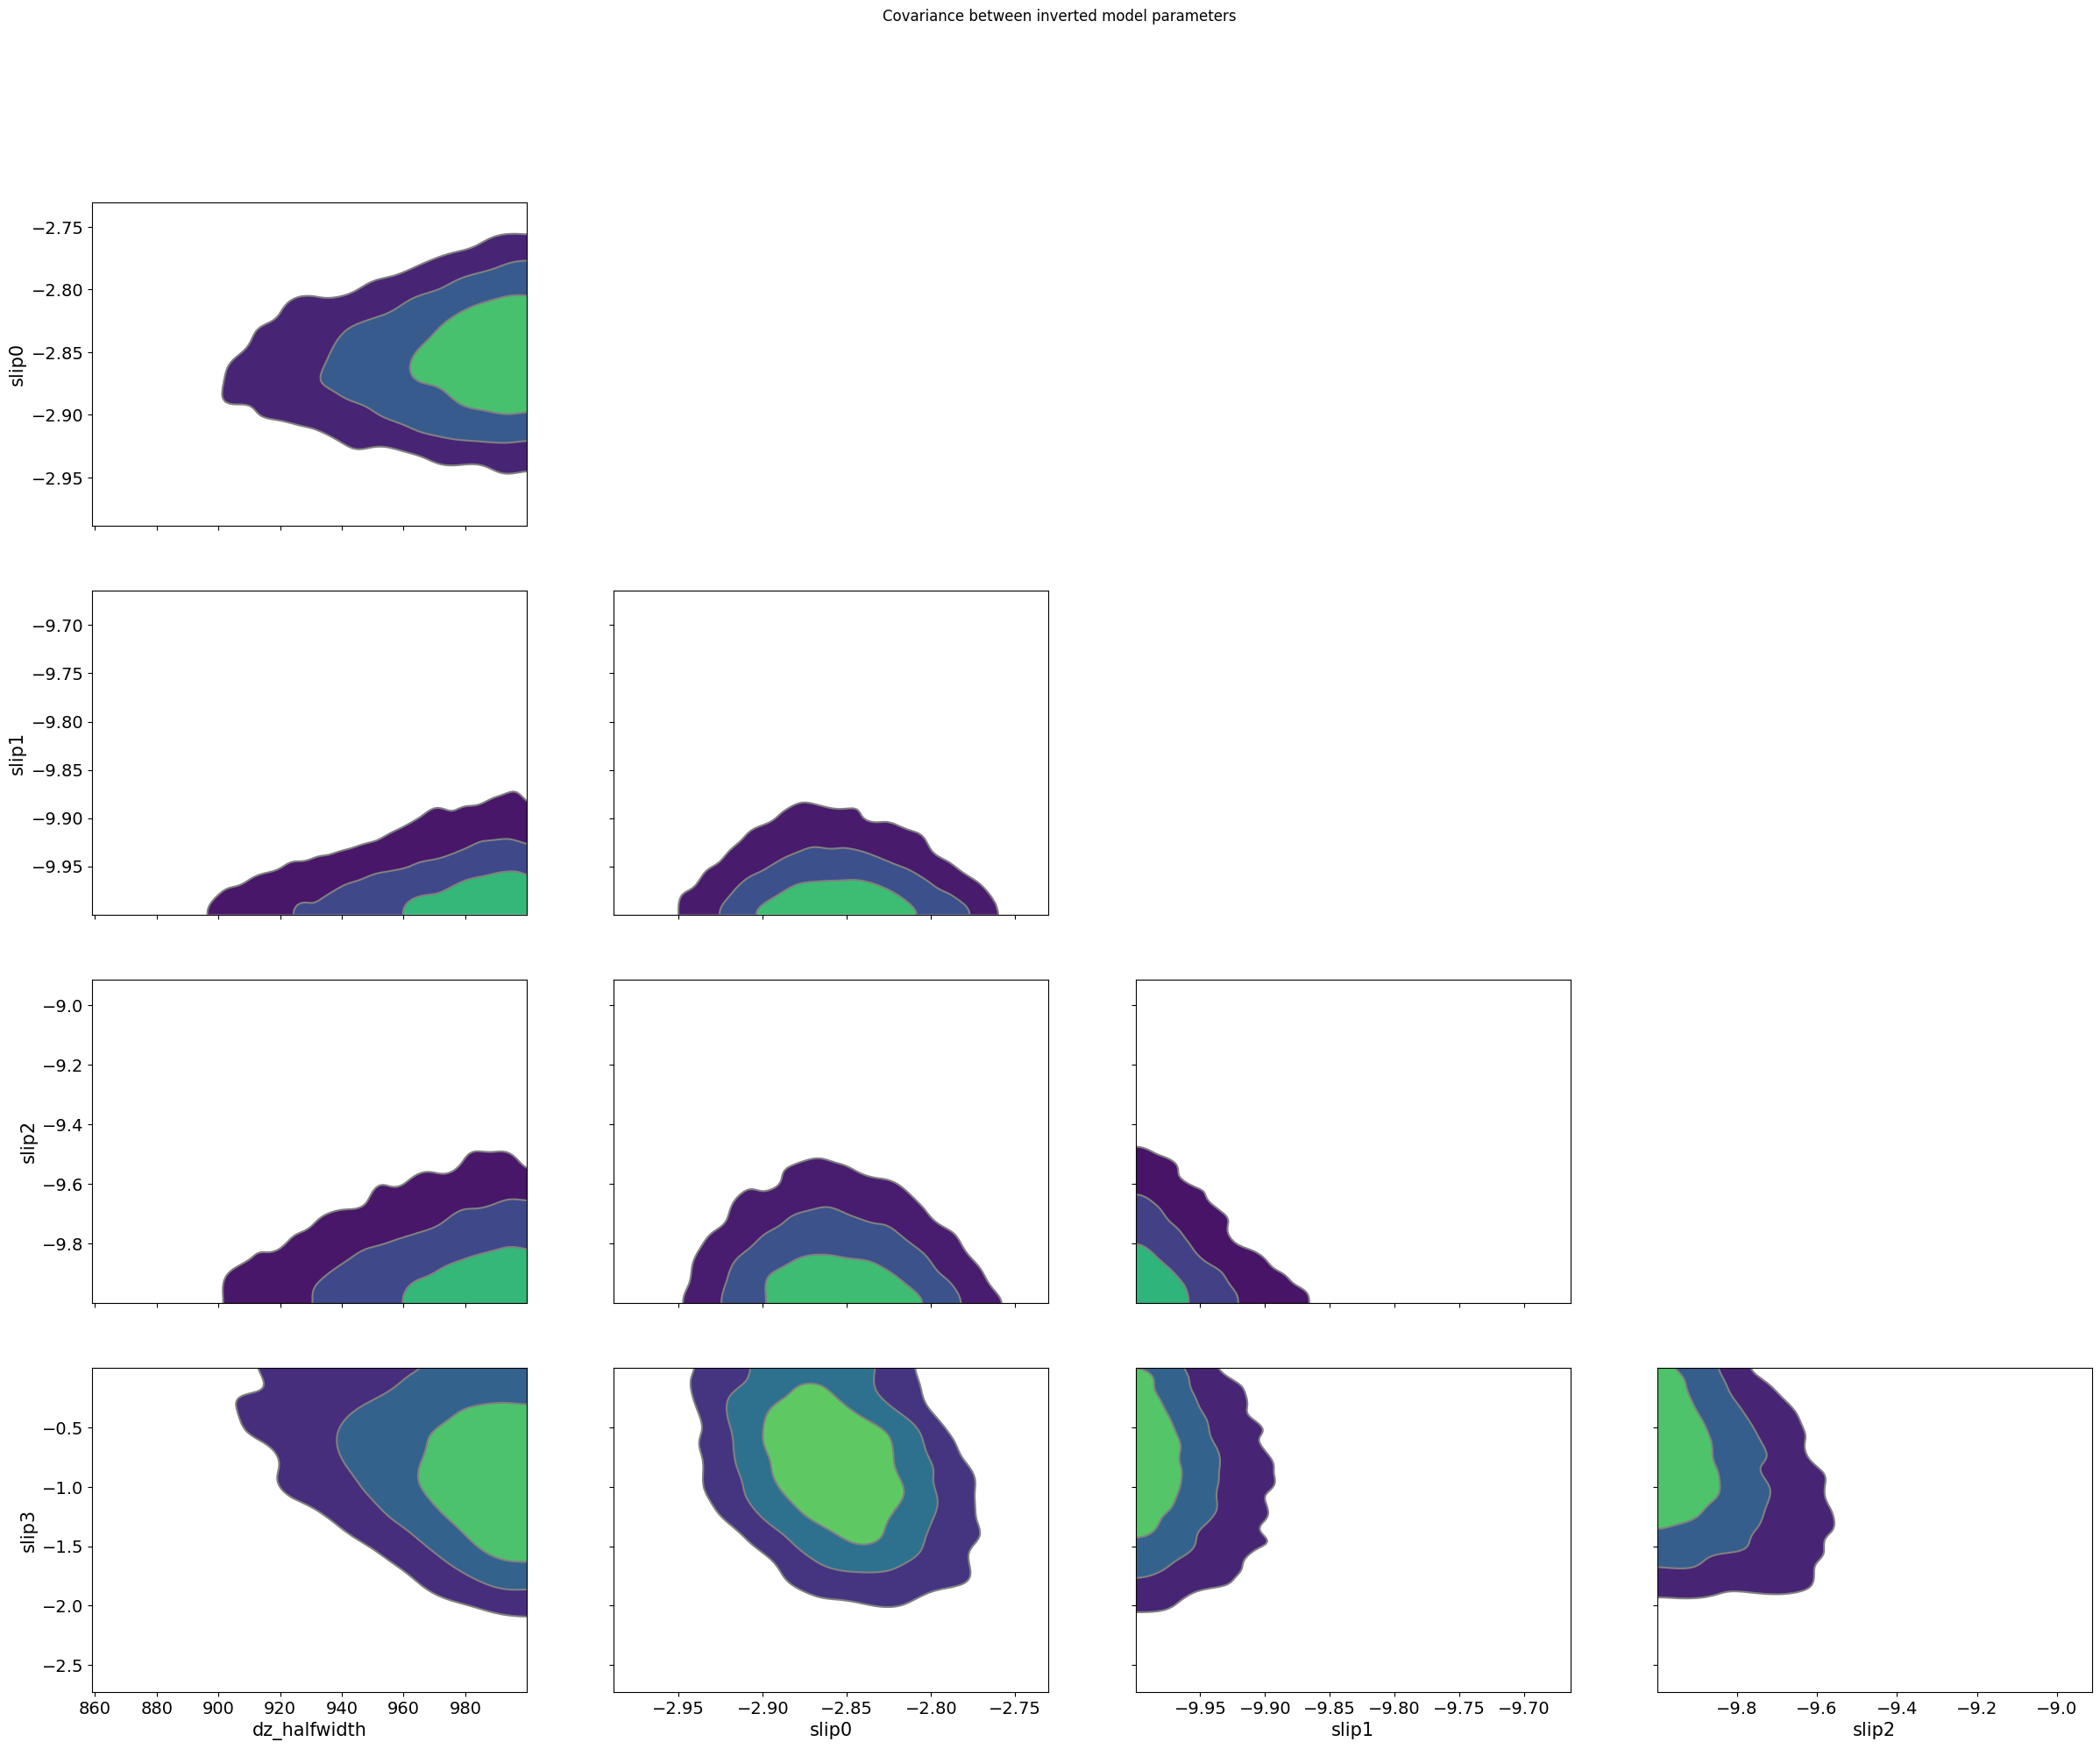

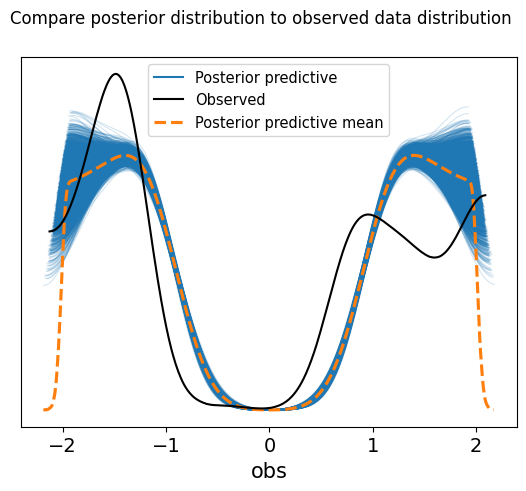

In [76]:
inversion.diagnostics()

In [78]:
# from codes import InversionManager
# # inversion = HamiltonianInversion(forward_model, priors, data, data_covariance)

# n_runs = len(profiles)
# inversions = InversionManager(
#     HamiltonianInversion,
#     (
#         [forward_model]*n_runs,
#         [priors]*n_runs,
#         [p.displacements[1] for p in profiles],
#         [data_covariance]*n_runs
#     ),
#     [f"Profile {i+1}" for i in range(n_runs)],
#     picklepath="/Users/hintont/Dev/codes/tests/results/inversions220126.pickle"
# )
# inversions = inversions.run()